In [1]:
import numpy as np
import matplotlib.pyplot as plt

import utils

Number of samples = 74561
Number of samples after thinning = 746
Number of samples = 101675
Number of samples after thinning = 1017
Number of samples = 80709
Number of samples after thinning = 808
Number of samples = 84213
Number of samples after thinning = 843


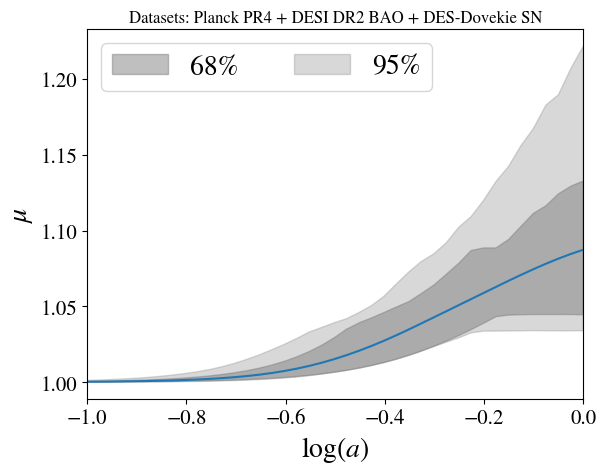

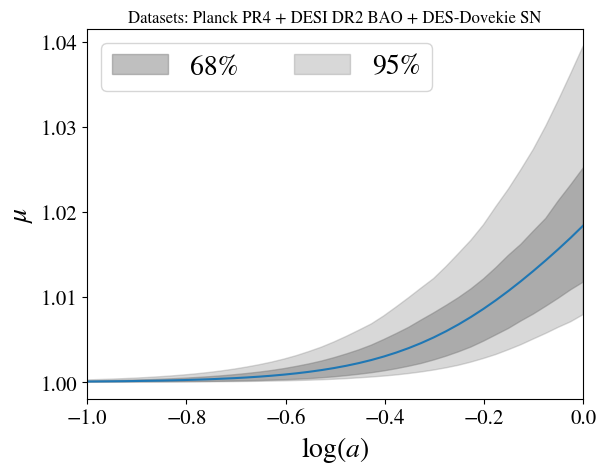

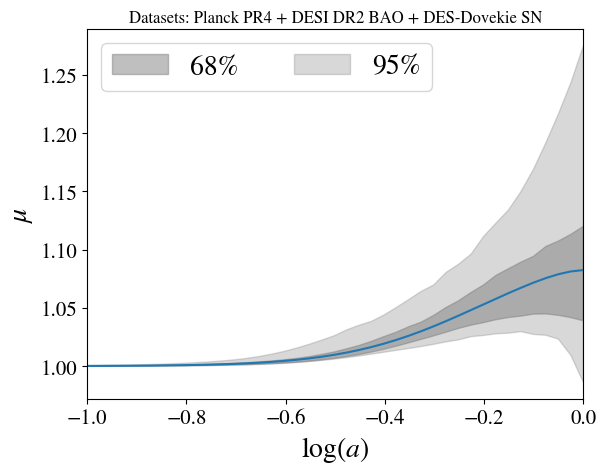

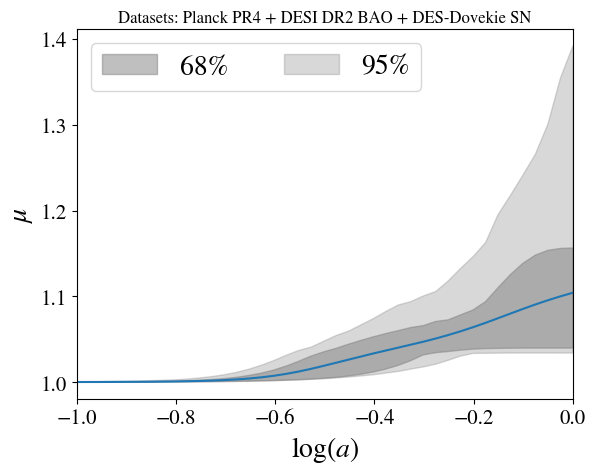

In [2]:
indices = range(64, 68)
names = ["omega", "kessence", "prop", "cugal"]
aktypes = [1, 2, 4, 3]

for i, name, aktype in zip(indices, names, aktypes):
    chain = utils.load_chain(i, burn_in=0.3)
    log_a, alpha_B, alpha_K, mus = utils.get_mu_alphas_from_chain(chain, aktype=aktype)

    plt.figure()
    plt.plot(log_a, np.mean(mus, axis=0))
    plt.fill_between(log_a, np.percentile(mus, 16, axis=0), np.percentile(mus, 84, axis=0), color="gray", alpha=0.5, label="68%")
    plt.fill_between(log_a, np.percentile(mus, 2.5, axis=0), np.percentile(mus, 97.5, axis=0), color="gray", alpha=0.3, label="95%")

    plt.xlim(-1, log_a[-1])
    plt.xlabel("$\\log(a)$", fontsize=20)
    plt.ylabel("$\\mu$", fontsize=20)
    plt.tick_params(axis="both", labelsize=15)
    plt.legend(fontsize=20, ncol=2, loc="upper left")
    plt.title("Datasets: Planck PR4 + DESI DR2 BAO + DES-Dovekie SN")
    
    plt.savefig(f"plots/constraint_mu_ds1_superluminal_{name}.pdf", bbox_inches="tight")